# FASE 08. Keyword spotting y detección de temas críticos

Esta fase analiza exclusivamente las transcripciones automáticas del pipeline. Conserva el diccionario, la normalización textual, las reglas de detección, las columnas, el score de criticidad y los outputs del notebook original.

El notebook mantiene visibles los pasos necesarios para entender y defender el análisis: restauración, consolidación, cobertura textual, inventario de temas, detección segmental, agregación por llamada, revisión cualitativa, análisis por rol/corpus e integración opcional con el sentimiento textual de la fase 07.

## 08.0 — Configuración del entorno

**Kernel requerido:** `Python (TFM_HuellaDeVoz)`

In [1]:
# INSTALACIÓN ACUMULADA DEL PROYECTO
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
requirements_path = REPO_ROOT / "requirements.txt"

%pip install -q -r {requirements_path}

Note: you may need to restart the kernel to use updated packages.


In [2]:
# IMPORTS Y ACCESO AL REPOSITORIO
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from google.cloud import storage
from IPython.display import display

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
SRC_DIR = REPO_ROOT / "src"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import keyword_spotting as ks
from src.config import (
    CALL_KEYWORDS_SENTIMENT_CSV,
    CALL_SENTIMENT_CSV,
    DATA_DIR,
    GCS_KEYWORD_PREFIX,
    GCS_UNAV_ROOT,
    KEYWORD_DIR,
    SENTIMENT_DIR,
    TRANSCRIPTION_ALL_SEGMENTS_CSV,
    TRANSCRIPTION_PER_AUDIO_DIR,
    TRANSCRIPTION_ROOT,
    ensure_phase08_directories,
)
from src.io_utils import csv_is_usable, write_csv_atomic
from src.storage_io import download_directory, upload_directory

In [3]:
# CONEXIÓN A GOOGLE CLOUD STORAGE
gcs_client = storage.Client()
print("Cliente GCS creado para el proyecto:", gcs_client.project)

Cliente GCS creado para el proyecto: mm-bi-catedras-upm


In [4]:
# CONFIGURACIÓN DE EJECUCIÓN
FORCE_KEYWORD_SPOTTING = False
FORCE_RESTORE = False
FORCE_RECONSOLIDATE_TRANSCRIPTIONS = False
TOP_N_CRITICAL_CALLS = 30

ensure_phase08_directories()

print("Repositorio:", REPO_ROOT)
print("Outputs locales:", KEYWORD_DIR)
print("Prefijo GCS fase 08:", GCS_KEYWORD_PREFIX)
print("Forzar keyword spotting:", FORCE_KEYWORD_SPOTTING)

Repositorio: /home/jupyter/TFM_ProcesadoDeAudios
Outputs locales: /home/jupyter/TFM_ProcesadoDeAudios/data/keyword_outputs
Prefijo GCS fase 08: gs://catedras_audio_detection/pipelineA/procesados_UNAV/keyword_outputs/
Forzar keyword spotting: False


## 08.1 — Restauración de outputs e inputs

Primero se restauran los outputs propios. Las transcripciones y el agregado de sentimiento textual solo se restauran cuando son necesarios; no se carga ningún modelo porque esta fase se basa en reglas deterministas.

In [5]:
# RESTAURAR OUTPUTS PREVIOS DE LA PROPIA FASE
restore_keyword = download_directory(
    local_dir=KEYWORD_DIR,
    gcs_prefix=GCS_UNAV_ROOT,
    gcs_client=gcs_client,
    base_dir=DATA_DIR,
)

keyword_outputs_ready = (
    ks.keyword_outputs_complete()
    and not FORCE_KEYWORD_SPOTTING
)

print("Restauración fase 08:", restore_keyword)
print("Outputs obligatorios completos:", keyword_outputs_ready)

Restauración desde GCS completada.
Archivos encontrados: 0
Archivos descargados: 0
Archivos locales ya vigentes: 0
Restauración fase 08: {'found': 0, 'downloaded': 0, 'skipped': 0}
Outputs obligatorios completos: True


In [6]:
# RESTAURAR TRANSCRIPCIONES Y SENTIMIENTO CUANDO CORRESPONDE
restore_transcription = None
restore_sentiment = None

if not keyword_outputs_ready or FORCE_RECONSOLIDATE_TRANSCRIPTIONS:
    restore_transcription = download_directory(
        local_dir=TRANSCRIPTION_ROOT,
        gcs_prefix=GCS_UNAV_ROOT,
        gcs_client=gcs_client,
        base_dir=DATA_DIR,
    )

# El sentimiento solo se utiliza para el output combinado opcional.
# Se restaura aunque el keyword spotting principal ya exista, porque el 07
# puede haberse actualizado después.
if FORCE_RESTORE or not csv_is_usable(
    CALL_SENTIMENT_CSV,
    required_columns=["audio_file", "avg_sentiment"],
):
    restore_sentiment = download_directory(
        local_dir=SENTIMENT_DIR,
        gcs_prefix=GCS_UNAV_ROOT,
        gcs_client=gcs_client,
        base_dir=DATA_DIR,
    )

print("Restauración transcripciones:", restore_transcription)
print("Restauración sentimiento:", restore_sentiment)

Restauración transcripciones: None
Restauración sentimiento: None


## 08.2 — Consolidación y control de transcripciones

Se conserva como fuente principal el consolidado `all_segments_transcribed.csv`. Si no existe o se fuerza la reconstrucción, se vuelve a generar desde los CSV por audio, manteniendo el nombre original.

In [7]:
if keyword_outputs_ready:
    loaded_outputs = ks.load_keyword_outputs()
    df_kw = loaded_outputs["segments"]
    call_level_keywords = loaded_outputs["calls"]
    top_critical_calls = loaded_outputs["top_calls"]
    print("Keyword spotting reutilizado; no se recalculan reglas ni agregados.")
else:
    df_transcriptions, transcription_source, n_per_audio_files = (
        ks.load_transcription_segments(
            per_audio_dir=TRANSCRIPTION_PER_AUDIO_DIR,
            consolidated_path=TRANSCRIPTION_ALL_SEGMENTS_CSV,
            force_consolidate=FORCE_RECONSOLIDATE_TRANSCRIPTIONS,
        )
    )
    print("Fuente utilizada:", transcription_source)
    print("CSV por audio disponibles:", n_per_audio_files)
    print("Dimensiones:", df_transcriptions.shape)
    print("Audios únicos:", df_transcriptions["audio_file"].nunique())
    print("Segmentos con texto:", int((df_transcriptions["n_chars"] > 0).sum()))
    print("Segmentos vacíos:", int((df_transcriptions["n_chars"] == 0).sum()))
    display(df_transcriptions.head())

Keyword spotting reutilizado; no se recalculan reglas ni agregados.


## 08.3 — Diccionario de temas críticos

El diccionario original contiene 12 grupos. Se normalizan mayúsculas, tildes, puntuación y espacios, y se eliminan duplicados dentro de cada tema. No se añaden ni eliminan palabras.

In [8]:
keyword_inventory = pd.DataFrame(
    [
        {
            "theme": theme,
            "n_keywords": len(keywords),
            "examples": ", ".join(keywords[:8]),
        }
        for theme, keywords in ks.CRITICAL_KEYWORDS.items()
    ]
)

print("Temas críticos definidos:", len(keyword_inventory))
print("Keywords normalizadas totales:", int(keyword_inventory["n_keywords"].sum()))
display(keyword_inventory)

Temas críticos definidos: 12
Keywords normalizadas totales: 501


,theme,n_keywords,examples
0,baja_cancelacion,43,"anular, baixa, baja, baja de fibra, baja de la..."
1,facturacion_cobros,62,"abono, cantidad incorrecta, cargo, cargo dupli..."
2,incidencia_tecnica,78,"apn, avaria, averia, averias, baja velocidad, ..."
3,reclamacion_queja,42,"abrir reclamacion, atencio al client, atencion..."
4,insatisfaccion_urgencia,56,"cabreada, cabreado, cansada, cansado, cuanto a..."
5,fraude_seguridad,46,"acces, acceso, app, area cliente, autorizacion..."
6,retencion_comercial,35,"cliente antiguo, competencia, compromiso de pe..."
7,espera_derivacion,35,"departament, departamento, derivacion, derivar..."
8,instalacion_citas,25,"alta de fibra, anular cita, cambiar cita, camb..."
9,alta_contratacion,25,"activacion, activar, activar servei, alta, alt..."


## 08.4 — Detección de keywords por segmento

La detección conserva la búsqueda por subcadena del notebook original. Para cada tema se generan las columnas `matched`, `count` y `flag`, además del número total de coincidencias y temas detectados por segmento.

In [9]:
if not keyword_outputs_ready:
    df_kw = ks.apply_keyword_spotting(df_transcriptions)

print("Segmentos analizados:", len(df_kw))
print("Segmentos con keyword crítica:", int(df_kw["has_critical_keyword"].sum()))
print(
    "Cobertura segmental:",
    round(df_kw["has_critical_keyword"].mean() * 100, 2),
    "%",
)

segment_review_columns = [
    column
    for column in [
        "audio_file",
        "start",
        "end",
        "speaker_final",
        "role_proxy",
        "text",
        "total_keyword_matches",
        "n_critical_themes",
        "critical_themes_detected",
    ]
    if column in df_kw.columns
]

display(
    df_kw.sort_values(
        ["total_keyword_matches", "n_critical_themes"],
        ascending=False,
    )[segment_review_columns].head(20)
)

Segmentos analizados: 40352
Segmentos con keyword crítica: 16878
Cobertura segmental: 41.83 %


,audio_file,start,end,speaker_final,text,total_keyword_matches,n_critical_themes,critical_themes_detected
17610,raw_bajas_9156561351300006851_clean.wav,181.656594,231.235344,SPEAKER_00,Cualquier comunicación a partir de ahora se va...,19,9,"['baja_cancelacion', 'facturacion_cobros', 'in..."
14068,raw_bajas_9156425565660006851_clean.wav,101.449719,149.138469,SPEAKER_00,"Ana. Vale, Ana. Te comento. Al realizar la con...",18,7,"['facturacion_cobros', 'incidencia_tecnica', '..."
25564,raw_bajas_9156994387760006851_clean.wav,26.035344,73.825344,SPEAKER_00,"dirigirme a ti, por favor? Mi nombre es Maribe...",16,9,"['baja_cancelacion', 'incidencia_tecnica', 're..."
12415,raw_bajas_9156329577480006851_clean.wav,93.315969,143.940969,SPEAKER_00,"Ahora mismo vosotros tenéis aquí dos líneas, ¿...",16,7,"['baja_cancelacion', 'facturacion_cobros', 'in..."
31755,raw_bajas_9157243717350006851_clean.wav,40.851594,80.254719,SPEAKER_01,"Claro, entonces te indico lo siguiente, digamo...",16,6,"['incidencia_tecnica', 'fraude_seguridad', 're..."
16455,raw_bajas_9156517979530006851_clean.wav,117.582219,145.628469,SPEAKER_01,Nosotros que hemos abierto una reclamación el ...,15,6,"['facturacion_cobros', 'incidencia_tecnica', '..."
19934,raw_bajas_9156682844120016851_clean.wav,59.650344,94.750344,SPEAKER_00,Excelente. Aquí lo tengo registrado en sistema...,14,4,"['baja_cancelacion', 'incidencia_tecnica', 'in..."
14055,raw_bajas_9156425565660006851_clean.wav,24.094719,57.490344,SPEAKER_00,"Ah, vale. En este caso se puede hacer un trasl...",14,3,"['incidencia_tecnica', 'instalacion_citas', 'g..."
34925,raw_bajas_9157338276050006851_clean.wav,61.439094,99.357219,SPEAKER_01,"Vale. Ángela María Jiménez Calderón. Vale, lo ...",13,8,"['baja_cancelacion', 'facturacion_cobros', 'in..."
1082,raw_9154438220380006851_clean.wav,149.172219,185.504094,SPEAKER_00,"Te comprendo. Vale, sí, yo te entiendo perfect...",13,7,"['facturacion_cobros', 'incidencia_tecnica', '..."


## 08.5 — Distribución de temas críticos

Esta tabla diferencia cuántos segmentos activan cada tema y cuántas coincidencias totales se observan.

,theme,n_segments,pct_segments,total_keyword_matches
0,incidencia_tecnica,8004,19.84,10912
1,baja_cancelacion,4067,10.08,5342
2,gestion_administrativa,3922,9.72,4814
3,fraude_seguridad,2365,5.86,3002
4,retencion_comercial,2198,5.45,2695
5,facturacion_cobros,2013,4.99,2674
6,instalacion_citas,2011,4.98,3252
7,espera_derivacion,1729,4.28,2672
8,vulnerabilidad_impacto,1484,3.68,1555
9,reclamacion_queja,964,2.39,1035


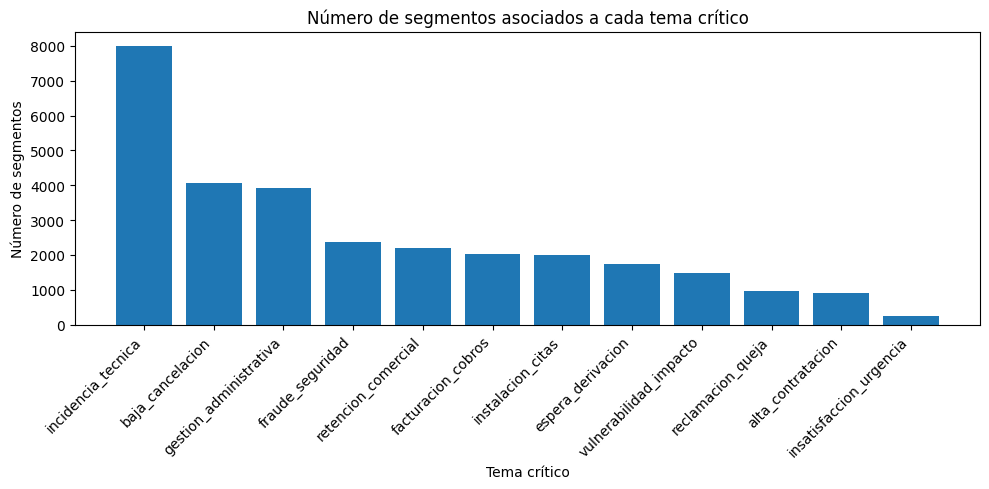

In [10]:
df_theme_summary = ks.build_theme_summary(df_kw)
display(df_theme_summary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_theme_summary["theme"], df_theme_summary["n_segments"])
ax.set_title("Número de segmentos asociados a cada tema crítico")
ax.set_xlabel("Tema crítico")
ax.set_ylabel("Número de segmentos")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
plt.tight_layout()
plt.show()

## 08.6 — Distribución por rol y corpus.

In [11]:
role_column = next(
    (
        column
        for column in ["role_proxy", "speaker_role", "role", "speaker_final"]
        if column in df_kw.columns
    ),
    None,
)
corpus_column = next(
    (
        column
        for column in ["source_dataset", "corpus", "dataset"]
        if column in df_kw.columns
    ),
    None,
)

if role_column:
    role_theme_summary = ks.build_group_theme_summary(df_kw, role_column)
    role_theme_pivot = role_theme_summary.pivot(
        index="theme",
        columns=role_column,
        values="pct_segments_with_theme",
    ).fillna(0)
    print("Distribución porcentual por:", role_column)
    display(role_theme_pivot)
else:
    role_theme_summary = pd.DataFrame()
    print("No se encontró una columna de rol para esta visualización.")

if corpus_column:
    corpus_theme_summary = ks.build_group_theme_summary(df_kw, corpus_column)
    corpus_theme_pivot = corpus_theme_summary.pivot(
        index="theme",
        columns=corpus_column,
        values="pct_segments_with_theme",
    ).fillna(0)
    print("Distribución porcentual por:", corpus_column)
    display(corpus_theme_pivot)
else:
    corpus_theme_summary = pd.DataFrame()
    print("No se encontró una columna de corpus para esta visualización.")

Distribución porcentual por: speaker_final


speaker_final,SPEAKER_00,SPEAKER_01
theme,,
alta_contratacion,2.34,2.14
baja_cancelacion,10.70,9.45
espera_derivacion,4.52,4.04
facturacion_cobros,5.03,4.95
fraude_seguridad,6.16,5.55
gestion_administrativa,10.25,9.18
incidencia_tecnica,20.41,19.26
insatisfaccion_urgencia,0.55,0.70
instalacion_citas,5.11,4.86


No se encontró una columna de corpus para esta visualización.


## 08.7 — Agregación y ranking por llamada

Se conserva el score original: cobertura segmental × 3, logaritmo del número de coincidencias y 0,5 por cada tema distinto detectado.

In [12]:
if not keyword_outputs_ready:
    call_level_keywords = ks.build_call_level_keywords(df_kw)
    top_critical_calls = ks.select_top_critical_calls(
        call_level_keywords,
        top_n=TOP_N_CRITICAL_CALLS,
    )

call_display_columns = [
    "audio_file",
    "n_segments",
    "n_segments_with_keywords",
    "pct_segments_with_keywords",
    "total_keyword_matches",
    "n_distinct_critical_themes",
    "critical_themes_detected",
    "keyword_criticality_score",
    "keyword_criticality_percentile",
]

display(top_critical_calls[call_display_columns])

,audio_file,n_segments,n_segments_with_keywords,pct_segments_with_keywords,total_keyword_matches,n_distinct_critical_themes,critical_themes_detected,keyword_criticality_score,keyword_criticality_percentile
0,raw_bajas_9156915870950006851_clean.wav,42,23,0.5476,67,12,"['baja_cancelacion', 'facturacion_cobros', 'in...",11.862308,1.0000
1,raw_bajas_9157425562410006851_clean.wav,42,24,0.5714,60,12,"['baja_cancelacion', 'facturacion_cobros', 'in...",11.825074,0.9992
2,raw_bajas_9155999629910006851_clean.wav,28,22,0.7857,82,10,"['baja_cancelacion', 'facturacion_cobros', 'in...",11.775941,0.9983
3,raw_bajas_9156260293450006851_clean.wav,48,30,0.6250,75,11,"['baja_cancelacion', 'facturacion_cobros', 'in...",11.705733,0.9975
4,raw_bajas_9156676921930016851_clean.wav,34,19,0.5588,49,12,"['baja_cancelacion', 'facturacion_cobros', 'in...",11.588423,0.9966
5,raw_bajas_9157356527550016851_clean.wav,57,28,0.4912,58,12,"['baja_cancelacion', 'facturacion_cobros', 'in...",11.551137,0.9958
6,raw_bajas_9156252819910006851_clean.wav,37,24,0.6486,58,11,"['baja_cancelacion', 'incidencia_tecnica', 're...",11.523337,0.9949
7,raw_bajas_9156336188520056851_clean.wav,38,25,0.6579,56,11,"['baja_cancelacion', 'facturacion_cobros', 'in...",11.516751,0.9941
8,raw_bajas_9156674191330016851_clean.wav,42,24,0.5714,71,11,"['baja_cancelacion', 'facturacion_cobros', 'in...",11.490866,0.9932
9,raw_bajas_9156683613980006851_clean.wav,56,26,0.4643,56,12,"['baja_cancelacion', 'facturacion_cobros', 'in...",11.435951,0.9924


## 08.8 — Revisión cualitativa de una llamada crítica

Se muestran todos los segmentos de la llamada con mayor score para comprobar que el ranking sea interpretable.

In [13]:
if not top_critical_calls.empty:
    sample_audio = top_critical_calls.iloc[0]["audio_file"]
    print("Llamada seleccionada:", sample_audio)

    qualitative_columns = [
        column
        for column in [
            "start",
            "end",
            "speaker_final",
            "role_proxy",
            "text",
            "total_keyword_matches",
            "n_critical_themes",
            "critical_themes_detected",
        ]
        if column in df_kw.columns
    ]
    display(
        df_kw[df_kw["audio_file"] == sample_audio]
        .sort_values(["start", "end"])[qualitative_columns]
    )
else:
    print("No hay llamadas disponibles para la revisión cualitativa.")

Llamada seleccionada: raw_bajas_9156915870950006851_clean.wav


,start,end,speaker_final,text,total_keyword_matches,n_critical_themes,critical_themes_detected
23651,1.330344,10.341594,SPEAKER_00,Muy buenos días. Hola. Te llamo del departamen...,4,2,"['baja_cancelacion', 'espera_derivacion']"
23652,10.341594,11.084094,SPEAKER_01,Correcto.,0,0,[]
23653,12.332844,24.381594,SPEAKER_00,"Vale. Antonio, hemos recibido en este caso un ...",4,4,"['baja_cancelacion', 'incidencia_tecnica', 'fr..."
23654,25.410969,28.752219,SPEAKER_01,"eso no, no tenía. Sí, sí. Ah, sí, sí pero no t...",0,0,[]
23655,29.410344,42.927219,SPEAKER_00,"Ah, vale. Listo. En este caso pues directament...",5,4,"['incidencia_tecnica', 'fraude_seguridad', 're..."
23656,43.652844,44.648469,SPEAKER_01,Evidentemente no.,0,0,[]
23657,46.335969,49.474719,SPEAKER_01,Solamente quiero dar de baja el teléfono. O se...,2,1,['baja_cancelacion']
23658,50.284719,54.233469,SPEAKER_01,Es una señora mayor con 96 años que viene a vi...,1,1,['vulnerabilidad_impacto']
23659,54.891594,61.945344,SPEAKER_00,"Vale, comprendo. En este caso, te pregunto, do...",1,1,['gestion_administrativa']
23660,66.585969,73.470969,SPEAKER_01,"complicado es esto, que si yo solamente da de ...",2,2,"['baja_cancelacion', 'alta_contratacion']"


## 08.9 — Integración con sentimiento textual

El notebook original combina el percentil de keywords (60 %) con la negatividad media textual (40 %). La ruta se toma de `config.py`, por lo que utiliza correctamente `call_level_sentiment_textual.csv` generado por la fase 07.

In [14]:
df_combined = None

if csv_is_usable(
    CALL_SENTIMENT_CSV,
    required_columns=["audio_file", "avg_sentiment"],
):
    call_sentiment = pd.read_csv(CALL_SENTIMENT_CSV)
    df_combined = ks.combine_keywords_with_sentiment(
        call_level_keywords,
        call_sentiment,
    )
    write_csv_atomic(df_combined, CALL_KEYWORDS_SENTIMENT_CSV)

    matched_sentiment = int(df_combined["avg_sentiment"].notna().sum())
    print("Llamadas con sentimiento correlacionado:", matched_sentiment)
    print("Total de llamadas:", len(df_combined))
    print("Output combinado:", CALL_KEYWORDS_SENTIMENT_CSV)
    display(df_combined.head(20))
else:
    print("No existe un agregado textual válido de la fase 07.")
    print("El keyword spotting principal permanece completo e independiente.")

Llamadas con sentimiento correlacionado: 1181
Total de llamadas: 1181
Output combinado: /home/jupyter/TFM_ProcesadoDeAudios/data/keyword_outputs/call_level_keywords_sentiment_combined.csv


,audio_file,n_segments_x,n_segments_with_text,n_segments_with_keywords,total_keyword_matches,n_theme_hits,total_duration_x,total_words_x,pct_segments_with_keywords,baja_cancelacion_segments,...,avg_sentiment,avg_confidence,pct_negative,pct_neutral,pct_positive,n_client_segments,n_agent_segments,call_sentiment_label,negative_sentiment_component,combined_criticality_score
0,raw_bajas_9157452496450006851_clean.wav,16,16,13,49,34,159.451875,571,0.8125,3,...,-0.500000,0.778315,0.500000,0.500000,0.000000,6,10,negative,0.500000,0.775100
1,raw_bajas_9156331182010026851_clean.wav,26,26,19,62,48,162.776250,620,0.7308,12,...,-0.423077,0.797964,0.461538,0.500000,0.038462,22,4,negative,0.423077,0.761611
2,raw_bajas_9156577789610016851_clean.wav,35,35,20,51,38,259.351875,826,0.5714,11,...,-0.411765,0.741315,0.470588,0.470588,0.058824,13,21,negative,0.411765,0.752526
3,raw_9154438220380006851_clean.wav,29,28,18,55,39,173.576250,562,0.6207,0,...,-0.423077,0.801976,0.423077,0.576923,0.000000,14,12,negative,0.423077,0.746371
4,raw_bajas_9156145960950016851_clean.wav,26,26,18,52,32,192.864375,533,0.6923,4,...,-0.400000,0.814869,0.480000,0.440000,0.080000,14,11,negative,0.400000,0.743740
5,raw_bajas_9157297477640006851_clean.wav,52,52,36,79,64,181.591875,767,0.6923,11,...,-0.403846,0.707698,0.442308,0.519231,0.038462,30,22,negative,0.403846,0.742758
6,raw_bajas_9156336102740006851_clean.wav,49,49,27,62,47,243.810000,759,0.5510,6,...,-0.346939,0.755363,0.346939,0.653061,0.000000,27,22,negative,0.346939,0.729656
7,raw_bajas_9156941613720006851_clean.wav,31,31,21,44,34,116.859375,439,0.6774,2,...,-0.387097,0.759918,0.387097,0.612903,0.000000,18,13,negative,0.387097,0.728919
8,raw_bajas_9156848840280006851_clean.wav,37,36,22,71,57,184.089375,675,0.5946,4,...,-0.352941,0.735092,0.382353,0.588235,0.029412,16,18,negative,0.352941,0.725936
9,raw_9154825192820016851_clean.wav,24,24,17,44,31,141.598125,416,0.7083,0,...,-0.434783,0.744761,0.478261,0.478261,0.043478,14,9,negative,0.434783,0.721593


## 08.10 — Guardado de outputs originales

No se crean CSV nuevos. Se conservan los tres outputs principales y, cuando existe sentimiento textual, el combinado original.

In [15]:
if not keyword_outputs_ready:
    saved_outputs = ks.save_keyword_outputs(
        df_kw=df_kw,
        call_level_keywords=call_level_keywords,
        top_critical_calls=top_critical_calls,
        combined=df_combined,
    )
else:
    saved_outputs = {
        name: path
        for name, path in ks.keyword_output_paths().items()
        if path.exists() and path.stat().st_size > 0
    }

print("Outputs disponibles:")
for output_name, output_path in saved_outputs.items():
    print(f"- {output_name}: {output_path}")

Outputs disponibles:
- segments: /home/jupyter/TFM_ProcesadoDeAudios/data/keyword_outputs/segments_with_keywords.csv
- calls: /home/jupyter/TFM_ProcesadoDeAudios/data/keyword_outputs/call_level_keywords.csv
- top_calls: /home/jupyter/TFM_ProcesadoDeAudios/data/keyword_outputs/top_critical_calls_keywords.csv
- combined: /home/jupyter/TFM_ProcesadoDeAudios/data/keyword_outputs/call_level_keywords_sentiment_combined.csv


## 08.11 — Resumen, sincronización y auditoría final

La subida se realiza únicamente bajo `GCS_KEYWORD_PREFIX` y omite archivos idénticos mediante `skip_unchanged=True`.

In [16]:
final_keyword_summary = ks.build_final_summary(
    df_kw=df_kw,
    call_level_keywords=call_level_keywords,
    theme_summary=df_theme_summary,
)

display(pd.DataFrame([final_keyword_summary]))

upload_keyword = upload_directory(
    local_dir=KEYWORD_DIR,
    gcs_prefix=GCS_KEYWORD_PREFIX,
    gcs_client=gcs_client,
    skip_unchanged=True,
)
print("Sincronización fase 08:", upload_keyword)

,n_audios_analyzed,n_segments_analyzed,n_segments_with_text,n_segments_with_keywords,pct_segments_with_keywords,n_calls_with_keywords,pct_calls_with_keywords,most_frequent_theme
0,1181,40352,38872,16878,41.83,1174,99.41,incidencia_tecnica


Subiendo outputs 1/4: call_level_keywords.csv
Subiendo outputs 2/4: call_level_keywords_sentiment_combined.csv
Subiendo outputs 3/4: segments_with_keywords.csv
Subiendo outputs 4/4: top_critical_calls_keywords.csv
Subida final completada.
Archivos locales revisados: 4
Archivos subidos: 4
Archivos omitidos sin cambios: 0
Destino: gs://catedras_audio_detection/pipelineA/procesados_UNAV/keyword_outputs/
Sincronización fase 08: {'total': 4, 'uploaded': 4, 'skipped': 0}


In [17]:
output_audit = pd.DataFrame(
    [
        {
            "output": output_name,
            "local_path": str(output_path),
            "exists": output_path.exists(),
            "size_bytes": output_path.stat().st_size if output_path.exists() else 0,
            "gcs_prefix": GCS_KEYWORD_PREFIX,
        }
        for output_name, output_path in ks.keyword_output_paths().items()
    ]
)

display(output_audit)

required_names = {"segments", "calls", "top_calls"}
missing_required = output_audit[
    output_audit["output"].isin(required_names)
    & ~output_audit["exists"]
]
if not missing_required.empty:
    raise RuntimeError(
        "Faltan outputs obligatorios de la fase 08: "
        f"{missing_required['output'].tolist()}"
    )

print("Fase 08 completada y auditada.")

,output,local_path,exists,size_bytes,gcs_prefix
0,segments,/home/jupyter/TFM_ProcesadoDeAudios/data/keywo...,True,48822858,gs://catedras_audio_detection/pipelineA/proces...
1,calls,/home/jupyter/TFM_ProcesadoDeAudios/data/keywo...,True,384766,gs://catedras_audio_detection/pipelineA/proces...
2,top_calls,/home/jupyter/TFM_ProcesadoDeAudios/data/keywo...,True,13254,gs://catedras_audio_detection/pipelineA/proces...
3,combined,/home/jupyter/TFM_ProcesadoDeAudios/data/keywo...,True,597593,gs://catedras_audio_detection/pipelineA/proces...


Fase 08 completada y auditada.
